In [1]:
import pickle
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from tqdm.auto import tqdm
from genkit import DDPMV, DLPMEps, DLPMEpsOrigin, GaussianFlowLinear
from genkit.datasets import fetch_synthetic_data
from genkit.inspect import estimate_init_error, estimate_training_loss_error, model_est_jacobian_spectral_curve
from genkit.metrics import metric_on_quantile, mmd_rbf, mssle, wasserstein_distance
from genkit.nn import MLPModel
from genkit.training import train
from genkit.visitor import CoreMetricsVisitor
from genkit.utils import format_duration
from labkit.report import PRETTY_RCPARAMS, summarize_metric_values, format_mean_std_latex


plt.rcParams.update(PRETTY_RCPARAMS)


/home/hcherkaoui/src/flowbench/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_specs = [
    {
        "name": "GF-Linear",
        "cls": GaussianFlowLinear,
        "source_distri": "Gaussian",
        "extra_kwargs": {},
        "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
        "color": "tab:blue",
        "linestyle": "dashdot",
        "marker": "^",
    },
    {
        "name": "DDPM-V",
        "cls": DDPMV,
        "source_distri": "Gaussian",
        "extra_kwargs": {},
        "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
        "color": "tab:green",
        "linestyle": "solid",
        "marker": "o",
    },
    {
        "name": "DLPM",
        "cls": DLPMEps,
        "source_distri": "Alpha-Stable",
        "extra_kwargs": {"alpha": 1.6, "reduce_type": "mean"},
        "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
        "color": "tab:purple",
        "linestyle": "dotted",
        "marker": "v",
    },
    {
        "name": "DLPM-Orig",
        "cls": DLPMEpsOrigin,
        "source_distri": "Alpha-Stable",
        "extra_kwargs": {"alpha": 1.6, "loss_monte_carlo": "mean"},
        "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
        "color": "tab:red",
        "linestyle": "dashed",
        "marker": "s",
    },
]


In [3]:
depth = 4
width = 128
time_dim = 32

n_steps = 128
n_epochs = 512
n_trials = 2
use_adamw = False
num_workers = 0

force_retrain = False
allow_train_if_cache_missing = True

device = "cuda" if torch.cuda.is_available() else "cpu"
fdtype = torch.float32
idtype = torch.int32

source_order = [spec["name"] for spec in model_specs]
source_colors = {spec["name"]: spec["color"] for spec in model_specs}
net_kwargs = {"width": width, "depth": depth, "time_dim": time_dim}
base_train_kwargs = {
    "n_epochs": n_epochs,
    "use_adamw": use_adamw,
    "num_workers": num_workers,
    "device": device,
}


In [ ]:
cache_path = "_02_explore_sandbox.pt"
model_cls_by_name = {spec["name"]: spec["cls"] for spec in model_specs}
source_distri_by_name = {spec["name"]: spec["source_distri"] for spec in model_specs}


def _serialize_run(run):
    state_dict = {key: value.detach().cpu() for key, value in run["generator"]._net.state_dict().items()}
    return {
        "trial_idx": run["trial_idx"],
        "model": run["model"],
        "source_distri": run["source_distri"],
        "extra_kwargs": dict(run["extra_kwargs"]),
        "train_kwargs": dict(run["train_kwargs"]),
        "training_loss": list(run["training_loss"]),
        "grad_variance_epoch": list(run["grad_variance_epoch"]),
        "grad_norm_epoch": list(run["grad_norm_epoch"]),
        "dim": int(run["generator"]._dim),
        "network_state_dict": state_dict,
    }


def _restore_run(payload):
    net = MLPModel(dim=int(payload["dim"]), **net_kwargs).to(device=device, dtype=fdtype)
    generator = model_cls_by_name[payload["model"]](
        net=net,
        dim=int(payload["dim"]),
        n_steps=n_steps,
        device=device,
        fdtype=fdtype,
        idtype=idtype,
        **payload["extra_kwargs"],
    )
    generator._net.load_state_dict(payload["network_state_dict"])
    generator._net.eval()
    return {
        "trial_idx": int(payload["trial_idx"]),
        "model": payload["model"],
        "source_distri": payload.get("source_distri", source_distri_by_name[payload["model"]]),
        "extra_kwargs": dict(payload["extra_kwargs"]),
        "train_kwargs": dict(payload["train_kwargs"]),
        "generator": generator,
        "training_loss": list(payload["training_loss"]),
        "grad_variance_epoch": list(payload["grad_variance_epoch"]),
        "grad_norm_epoch": list(payload["grad_norm_epoch"]),
    }


def _load_cache_payload(path):
    try:
        return torch.load(path, map_location=device)
    except pickle.UnpicklingError:
        return torch.load(path, map_location=device, weights_only=False)


def _normalize_run_payload(run_payload):
    if "network_state_dict" in run_payload:
        return _restore_run(run_payload)
    if "generator" in run_payload:
        return _restore_run(_serialize_run(run_payload))
    raise ValueError(f"Unsupported cached run payload keys: {sorted(run_payload.keys())}")


print(cache_path)


_results/sandbox/02_heavytail_loss_training.pt


In [5]:
use_cache = cache_path.exists() and not force_retrain
can_train = allow_train_if_cache_missing or force_retrain

if use_cache:
    payload = _load_cache_payload(cache_path)
    runs = [_normalize_run_payload(run_payload) for run_payload in payload["runs"]]
    trial_refs = {
        int(key): value.to(device=device, dtype=fdtype)
        for key, value in payload["trial_refs"].items()
    }
else:
    if not can_train:
        raise FileNotFoundError(
            f"Missing cache at {cache_path}. Set allow_train_if_cache_missing=True or force_retrain=True."
        )

    runs = []
    trial_refs = {}
    run_idx = 0

    for trial_idx in range(n_trials):
        x_train, x_val, x_ref = fetch_synthetic_data(
            "alpha_stable",
            alpha=1.6,
            n_samples=70_000,
            val_size=0.1,
            test_size=0.1,
            dim=15,
            device=device,
            dtype=fdtype,
        )
        n_samples, dim = x_train.shape
        trial_refs[trial_idx] = x_ref[: min(n_samples, x_ref.shape[0])].clone()

        for spec in model_specs:
            run_idx += 1
            core_visitor = CoreMetricsVisitor()
            net = MLPModel(dim=dim, **net_kwargs).to(device=device, dtype=fdtype)
            generator = spec["cls"](
                net=net,
                dim=dim,
                n_steps=n_steps,
                device=device,
                fdtype=fdtype,
                idtype=idtype,
                **spec["extra_kwargs"],
            )
            run_train_kwargs = {**base_train_kwargs, **spec.get("train_kwargs", {})}

            t0 = time.perf_counter()
            print(
                f"[{run_idx:02d}/{len(model_specs) * n_trials:02d}] trial {trial_idx + 1}/{n_trials} {spec['name']}: "
                f"Training (nb train samples: {n_samples}, nb test samples: {len(x_ref)}, nb val samples: {len(x_val)}, "
                f"dim: {dim}, max: {x_train.max():.1f}, min: {x_train.min():.1f}, lr: {run_train_kwargs['lr']:.1e}, "
                f"batch: {run_train_kwargs['batch_size']}, clip: {run_train_kwargs['grad_clip_norm']})...",
                end="",
            )
            generator, diagnostics = train(
                generative_model=generator,
                target_data=x_train.clone(),
                visitors=[core_visitor],
                **run_train_kwargs,
            )
            print(f"Done (in {format_duration(time.perf_counter() - t0)}).")

            runs.append(
                {
                    "trial_idx": trial_idx,
                    "model": spec["name"],
                    "source_distri": spec["source_distri"],
                    "extra_kwargs": dict(spec["extra_kwargs"]),
                    "train_kwargs": dict(run_train_kwargs),
                    "generator": generator,
                    "training_loss": diagnostics.get("visitors", {}).get("core", {}).get("training_loss", []),
                    "grad_variance_epoch": diagnostics.get("visitors", {}).get("core", {}).get("grad_variance_epoch", []),
                    "grad_norm_epoch": diagnostics.get("visitors", {}).get("core", {}).get("grad_norm_epoch", []),
                }
            )

    torch.save(
        {
            "runs": [_serialize_run(run) for run in runs],
            "trial_refs": {
                trial_idx: value.detach().cpu()
                for trial_idx, value in trial_refs.items()
            },
        },
        cache_path,
    )


[01/08] trial 1/2 GF-Linear: Training (nb train samples: 55999, nb test samples: 7000, nb val samples: 7001, dim: 15, max: 2242.2, min: -1743.3, lr: 5.0e-03, batch: 1024, clip: 10.0)...Done (in 7min 44s).
[02/08] trial 1/2 DDPM-V: Training (nb train samples: 55999, nb test samples: 7000, nb val samples: 7001, dim: 15, max: 2242.2, min: -1743.3, lr: 5.0e-03, batch: 1024, clip: 10.0)...Done (in 7min 40s).
[03/08] trial 1/2 DLPM: Training (nb train samples: 55999, nb test samples: 7000, nb val samples: 7001, dim: 15, max: 2242.2, min: -1743.3, lr: 5.0e-03, batch: 1024, clip: 10.0)...Done (in 8min 9s).
[04/08] trial 1/2 DLPM-Orig: Training (nb train samples: 55999, nb test samples: 7000, nb val samples: 7001, dim: 15, max: 2242.2, min: -1743.3, lr: 5.0e-03, batch: 1024, clip: 10.0)...Done (in 8min 23s).
[05/08] trial 2/2 GF-Linear: Training (nb train samples: 55999, nb test samples: 7000, nb val samples: 7001, dim: 15, max: 856.6, min: -982.2, lr: 5.0e-03, batch: 1024, clip: 10.0)...Done (

In [6]:
metric_xis = {"MSSLE_95": 0.95, "MSSLE_99": 0.99, "MSSLE_999": 0.999}
xis = np.unique(np.round(1 - np.logspace(-1, -3, 7), 6))
probe_size = min(128, min(len(x_ref) for x_ref in trial_refs.values()))
eval_n_samples = min(len(x_ref) for x_ref in trial_refs.values())
curve_runs = {name: [run for run in runs if run["model"] == name] for name in source_order}
jacobian_runs = {name: [] for name in source_order}


def _mean_curve(model_runs, key):
    curves = [np.asarray(run[key], dtype=float) for run in model_runs if run[key]]
    size = min(len(curve) for curve in curves)
    values = np.stack([curve[:size] for curve in curves], axis=0)
    return values.mean(axis=0)


def _loss_family_label(run):
    tag = getattr(run["generator"], "_loss_tag", "other")
    return {"mse": "MSE loss", "sqrt_mse": "sqrt(MSE) loss"}.get(tag, f"{tag} loss")


In [7]:
eval_rows = []
tail_curves = []
inspect_rows = []
failures = []
loss_family_by_model = {}

for run in tqdm(runs, desc="Evaluating runs"):
    loss_family_by_model.setdefault(run["model"], _loss_family_label(run))
    x_ref = trial_refs[run["trial_idx"]][:eval_n_samples, :]
    x_gen = run["generator"].sample(n_samples=len(x_ref))

    eval_rows.append(
        {
            "model": run["model"],
            "trial_idx": run["trial_idx"],
            "source_distri": run["source_distri"],
            "WASS": float(wasserstein_distance(x_ref, x_gen)),
            "MMD_RBF": float(mmd_rbf(x_ref, x_gen)),
            **{
                name: float(metric_on_quantile(mssle, x_ref, x_gen, xi=float(xi), reduction="mean"))
                for name, xi in metric_xis.items()
            },
        }
    )
    tail_curves.append(
        {
            "model": run["model"],
            "trial_idx": run["trial_idx"],
            "mssle": np.array(
                [metric_on_quantile(mssle, x_ref, x_gen, xi=float(xi), reduction="mean") for xi in xis]
            ),
        }
    )

    x_probe = x_ref[:probe_size, :]
    try:
        inspect_rows.append(
            {
                "model": run["model"],
                "trial_idx": run["trial_idx"],
                "err_init": estimate_init_error(run["generator"], x_ref, n_samples=min(4096, len(x_ref)), k=10),
                "err_train": estimate_training_loss_error(run["generator"], x_ref, n_batches=16, batch_size=min(256, len(x_ref)), loss_type="mse"),
            }
        )
        curve, t_grid = model_est_jacobian_spectral_curve(run["generator"], x_probe, n_power_iter=8)
        jacobian_runs[run["model"]].append((np.asarray(t_grid, dtype=float), np.asarray(curve, dtype=float)))
    except Exception as exc:
        failures.append({"trial_idx": run["trial_idx"], "model": run["model"], "error": str(exc)})

for failure in failures:
    print(f'Error occurred for trial {failure["trial_idx"] + 1} ({failure["model"]}): {failure["error"]}')


Evaluating runs: 100%|██████████| 8/8 [05:23<00:00, 40.38s/it]

Error occurred for trial 1 (DLPM-Orig): 'inspect' utilities can only inspect 'diffusion' or 'flow' models, got vendor.
Error occurred for trial 2 (DLPM-Orig): 'inspect' utilities can only inspect 'diffusion' or 'flow' models, got vendor.


In [8]:
eval_df = pd.DataFrame(eval_rows)
summary_rows = []
for model_name in source_order:
    model_df = eval_df[eval_df["model"] == model_name]
    row = {"model": model_name}
    for metric_name in ("WASS", "MMD_RBF", "MSSLE_95", "MSSLE_99", "MSSLE_999"):
        stats = summarize_metric_values(model_df[metric_name].tolist())
        row[metric_name] = stats["mean"]
        row[f"{metric_name}_std"] = stats["std"]
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index("model").loc[source_order]

formatted = summary_df[["WASS", "MMD_RBF", "MSSLE_95", "MSSLE_99", "MSSLE_999"]].copy().astype(object)
for metric_name in formatted.columns:
    best_model = summary_df[metric_name].idxmin()
    for model_name in formatted.index:
        formatted.loc[model_name, metric_name] = format_mean_std_latex(
            summary_df.loc[model_name, metric_name],
            summary_df.loc[model_name, f"{metric_name}_std"],
            bold=model_name == best_model,
        )

inspect_df = pd.DataFrame(inspect_rows)
inspect_summary = pd.DataFrame(
    [
        {
            "model": model_name,
            "err_init": summarize_metric_values(inspect_df.loc[inspect_df["model"] == model_name, "err_init"].tolist()),
            "err_train": summarize_metric_values(inspect_df.loc[inspect_df["model"] == model_name, "err_train"].tolist()),
        }
        for model_name in source_order
    ]
).set_index("model").loc[source_order]


In [9]:
avg_loss_by_model = {name: _mean_curve(curve_runs[name], "training_loss") for name in source_order}
avg_grad_var_by_model = {name: _mean_curve(curve_runs[name], "grad_variance_epoch") for name in source_order}
avg_grad_norm_by_model = {name: _mean_curve(curve_runs[name], "grad_norm_epoch") for name in source_order}
loss_groups = {}
for name in source_order:
    loss_groups.setdefault(loss_family_by_model[name], []).append(name)

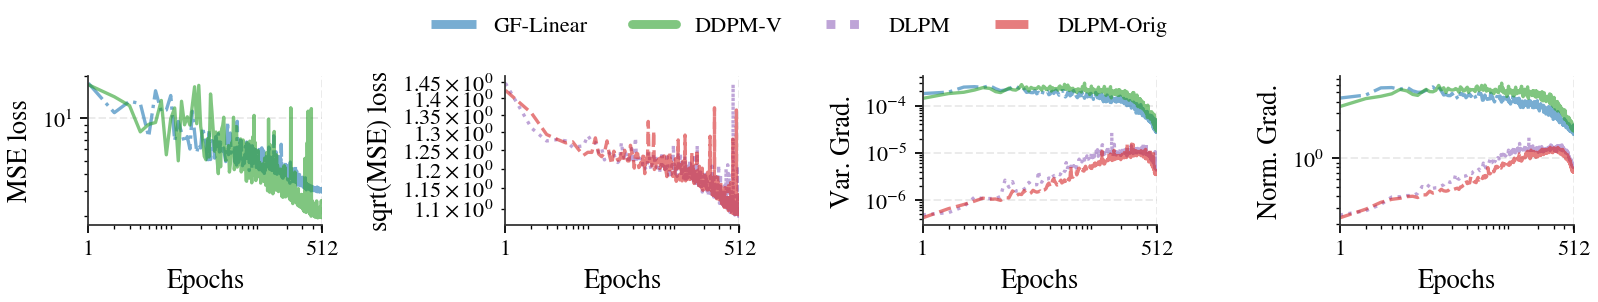

In [10]:
loss_labels = list(loss_groups)
fig, axis = plt.subplots(1, len(loss_labels) + 2, figsize=(3.0 * len(loss_labels) + 4.25, 2.0), squeeze=False)

for idx, loss_label in enumerate(loss_labels):
    ax = axis[0, idx]
    model_names = loss_groups[loss_label]
    max_epochs = max(avg_loss_by_model[name].size for name in model_names)
    for spec in model_specs:
        name = spec["name"]
        if name not in model_names:
            continue
        ax.plot(np.arange(1, avg_loss_by_model[name].size + 1), avg_loss_by_model[name], color=source_colors[name], linestyle=spec["linestyle"], lw=1.5, alpha=0.6)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1, max_epochs)
    ax.set_xticks([1, max_epochs], ["1", f"{max_epochs}"])
    ax.set_xlabel("Epochs")
    ax.set_ylabel(loss_label)

max_grad_var_epochs = max(curve.size for curve in avg_grad_var_by_model.values())
max_grad_norm_epochs = max(curve.size for curve in avg_grad_norm_by_model.values())

for spec in model_specs:
    name = spec["name"]
    color = source_colors[name]
    axis[0, -2].plot(np.arange(1, avg_grad_var_by_model[name].size + 1), avg_grad_var_by_model[name], color=color, linestyle=spec["linestyle"], lw=1.5, alpha=0.6)
    axis[0, -1].plot(np.arange(1, avg_grad_norm_by_model[name].size + 1), avg_grad_norm_by_model[name], color=color, linestyle=spec["linestyle"], lw=1.5, alpha=0.6)

axis[0, -2].set_xscale("log")
axis[0, -2].set_yscale("log")
axis[0, -2].set_xlim(1, max_grad_var_epochs)
axis[0, -2].set_xticks([1, max_grad_var_epochs], ["1", f"{max_grad_var_epochs}"])
axis[0, -2].set_xlabel("Epochs")
axis[0, -2].set_ylabel("Var. Grad.")

axis[0, -1].set_xscale("log")
axis[0, -1].set_yscale("log")
axis[0, -1].set_xlim(1, max_grad_norm_epochs)
axis[0, -1].set_xticks([1, max_grad_norm_epochs], ["1", f"{max_grad_norm_epochs}"])
axis[0, -1].set_xlabel("Epochs")
axis[0, -1].set_ylabel("Norm. Grad.")

legend_handles = [
    Line2D([0], [0], color=source_colors[spec["name"]], lw=4.0, linestyle=spec["linestyle"], label=spec["name"], alpha=0.6)
    for spec in model_specs
]
fig.legend(legend_handles, [handle.get_label() for handle in legend_handles], loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=len(model_specs), frameon=False, fontsize=10)
fig.tight_layout(rect=(0, 0, 1.0, 0.86))
plt.show()


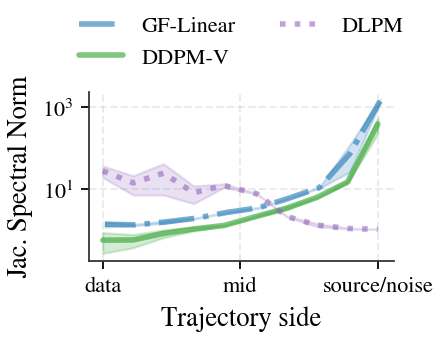

In [11]:
fig, axis = plt.subplots(1, 1, figsize=(3.0, 2.4), squeeze=False)

x_left, x_right = 1.0, float(n_steps)

for spec in model_specs:
    curves = jacobian_runs[spec["name"]]
    if not curves:
        continue
    min_len = min(len(curve) for _, curve in curves)
    t_grid = curves[0][0][:min_len].astype(float)
    values = np.stack([curve[:min_len] for _, curve in curves], axis=0)
    avg_curve = values.mean(axis=0)
    std_curve = values.std(axis=0)
    x_plot = t_grid.copy()
    if spec["name"] == "GF-Linear":
        x_plot = x_right + x_left - x_plot
    axis[0, 0].plot(x_plot, avg_curve, color=source_colors[spec["name"]], linestyle=spec["linestyle"], lw=2.5, alpha=0.6, label=spec["name"])
    axis[0, 0].fill_between(x_plot, avg_curve - std_curve, avg_curve + std_curve, color=source_colors[spec["name"]], alpha=0.2)

axis[0, 0].set_yscale("log")
xticks = [x_left, 0.5 * (x_left + x_right), x_right]
axis[0, 0].set_xticks(xticks, ["data", "mid", "source/noise"])
axis[0, 0].set_xlabel("Trajectory side")
axis[0, 0].set_ylabel("Jac. Spectral Norm")
axis[0, 0].legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=10)

fig.tight_layout()
plt.show()


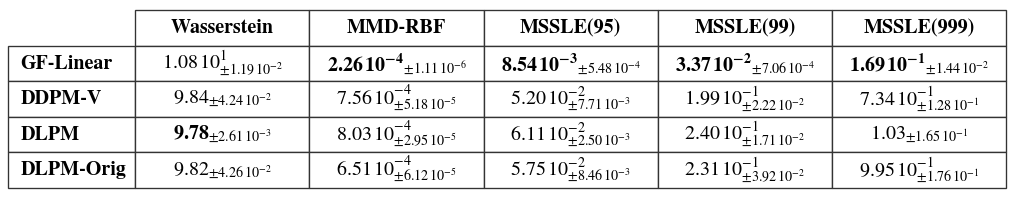

In [12]:
fig, axis = plt.subplots(1, 1, figsize=(6.6, 1.5), squeeze=False)

axis[0, 0].axis("off")
table = axis[0, 0].table(
    cellText=formatted.values,
    rowLabels=formatted.index,
    colLabels=["Wasserstein", "MMD-RBF", "MSSLE(95)", "MSSLE(99)", "MSSLE(999)"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.35)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("0.2")
    cell.set_linewidth(0.6)
    if row == 0 or col == -1:
        cell.set_text_props(weight="bold")

fig.tight_layout()
plt.show()


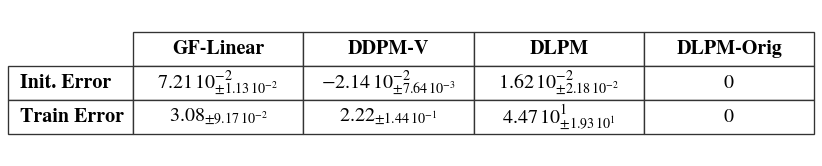

In [13]:
inspect_table = pd.DataFrame(index=["err_init", "err_train"], columns=source_order, dtype=object)

for model_name in source_order:
    for metric_name in ["err_init", "err_train"]:
        stats = inspect_summary.loc[model_name, metric_name]
        inspect_table.loc[metric_name, model_name] = format_mean_std_latex(
            stats["mean"],
            stats["std"],
            bold=False,
        )

fig, axis = plt.subplots(1, 1, figsize=(5.4, 1.3), squeeze=False)
axis[0, 0].axis("off")
table = axis[0, 0].table(
    cellText=inspect_table.values,
    rowLabels=["Init. Error", "Train Error"],
    colLabels=source_order,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.35)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("0.2")
    cell.set_linewidth(0.6)
    if row == 0 or col == -1:
        cell.set_text_props(weight="bold")

fig.tight_layout()
plt.show()


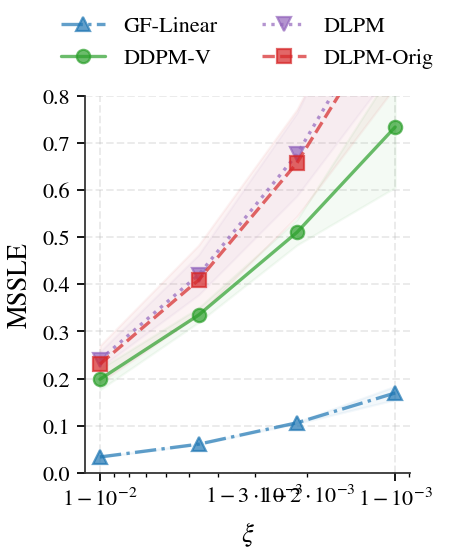

In [14]:
start = 3  # Skip the first two points which are too close to 0
fig, axes = plt.subplots(1, 1, figsize=(3, 3.75), sharex=True, squeeze=False)

for spec in model_specs:
    model_curves = [curve for curve in tail_curves if curve["model"] == spec["name"]]
    if not model_curves:
        continue
    avg_curve = np.mean(np.stack([curve['mssle'] for curve in model_curves], axis=0), axis=0)[start:]
    std_curve = np.std(np.stack([curve['mssle'] for curve in model_curves], axis=0), axis=0)[start:]
    axes[0, 0].plot(xis[start:], avg_curve, lw=1.5, color=source_colors[spec["name"]], linestyle=spec["linestyle"], marker=spec["marker"], label=spec["name"], alpha=0.7)
    axes[0, 0].fill_between(xis[start:], avg_curve - std_curve, avg_curve + std_curve, color=source_colors[spec["name"]], alpha=0.05)

axes[0, 0].set_ylim(bottom=0, top=0.8)
axes[0, 0].set_xscale("logit")
axes[0, 0].set_xlabel(r"$\xi$")
axes[0, 0].set_ylabel("MSSLE")

axes[0, 0].legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=10)

fig.tight_layout()
plt.show()
